In [2]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm
from devito import configuration
PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = "../data/21-20.sgy"
NBL=500
SO=4

configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"

def setup_model_and_geometry(iter_num):
    """Set up the velocity model and acquisition geometry"""
    dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
    xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
    spacing = (0.025, 0.025)
    velmodel = VelocityModel(
        PATH_MODEL,
        dx=spacing[0],
        dz=spacing[1],
        clip=True,
        xmin=xmin - 3,
        xmax=xmax + 3,
        zmin=-318,
    )
    velmodel.pad_left(4 + 2)
    velmodel.pad_right(8 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_bottom(10 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_top(7 * int(0.5 / spacing[0]))

    vp = velmodel.vp.T
    origin = velmodel.x[0], velmodel.z[0]
    model = SeismicModel(
        vp=vp,
        origin=origin,
        shape=vp.shape,
        spacing=spacing,
        space_order=SO,
        nbl=NBL,
        bcs="damp",
        fs=False,
    )
    return model, dataset

In [3]:
model, dataset = setup_model_and_geometry(0)

Operator `initdamp` ran in 0.16 s


In [4]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]

t0 = 0
tn = 70.0

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
frequencies = np.linspace(0.05, 0.5, num=20).tolist()
rec, u, freq_modes, summary = solver.green(frequencies=frequencies)

Operator `Forward` ran in 167.33 s


In [7]:
freq_modes[0]

freq_modes[0]

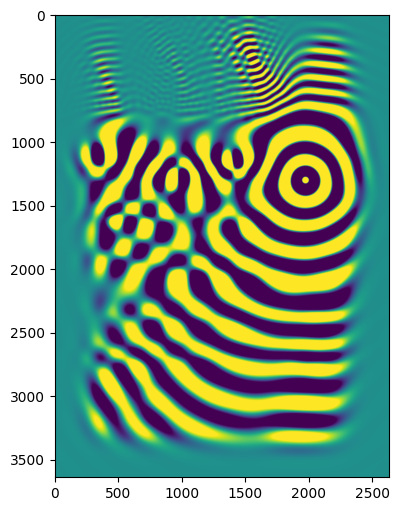

In [16]:
from matplotlib import pyplot as plt
plt.imshow(freq_modes.data[19].T.real, vmin=-0.001, vmax=0.001)
plt.show()